# Playground - Part II

🎯 **Hedef**: ***Sinir Ağı hiperparametreleri*** hakkında daha iyi bir anlayış kazanmak

<hr>

👉  [Playground](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=3&seed=0.06711&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false&regularization_hide=false&regularizationRate_hide=false) tekrar açın. 

❗️ Algoritma stokastik olduğundan, sonuçların her çalıştırmada farklılık gösterebileceğini unutmayın. Bu nedenle, Sinir Ağlarınızın davranışını analiz etmek ve buna göre sonuçlarınızı çıkarmak için algoritmaları birden çok kez çalıştırmaktan çekinmeyin.

🕵🏻 Ders sırasında gördüğümüz farklı öğeleri inceleyelim:
- **Batch Size**
- **Regularization**
- **Learning Rate**

## (1) The batch size

❓ **İlk Soru** ❓ `circle dataset` (Sınıflandırma) seçin.

* Aşağıdakilerle bir model oluşturun:
* 3 nöronlu bir gizli katman,
* 0,03'e eşit bir a _learning rate_
* ve _tanh_ aktivasyon fonksiyonu

* Herhangi bir gürültü eklemeyin (=0).

* 30'luk bir batch size seçin

***Algoritmanın yakınsamasını inceleyin. Yavaş mı yoksa hızlı mı görünüyor?***

> <i>> Yakınsama **düzgün ve görece hızlı**: train ve test loss birlikte, dalgalanmadan düşüyor; daire birkaç yüz epoch içinde ayrılıyor.
> 30 örneğin ortalama gradyanı gerçek gradyana yakın olduğu için her adım tutarlı bir yönde. (beklenen davranış)</i>

❓ **Soru: 1'lik batch size' da ne oluyor?** ❓

Şimdi, bu sinir ağını aynı veri kümesinde çalıştırın, ancak...

* batch-size 1 olsun.
* En az 150 dönem çalıştırdığınızdan emin olun.

***Eğitim ve test kaybı hakkında ne fark ettiniz? Bu istikrarsızlığın nedeni nedir?***

> <i>b> Loss eğrileri **çok zıplıyor (gürültülü)**. Sebep: her güncelleme **tek bir örneğin** gradyanına dayanıyor.
> Tek örnek tüm veriyi temsil etmediği için ağırlıklar her adımda farklı yöne itiliyor (stochastic gradient descent).
> Avantajı: epoch başına çok daha fazla güncelleme yapılıyor; gürültü bazen kötü yerel minimumlardan kaçmaya da yardım ediyor. (beklenen davranış)</i>

❓ **Soru/Gözlem** ❓

Şimdi, tren kaybı ve test kaybı değerlerini okuyarak _batch_size_'ın etkisini görebilirsiniz: yinelemeleri duraklatın ve `“Adım”` düğmesini (play/stop düğmesinin sağ tarafında) kullanarak adım adım (yineleme başına yineleme) çalıştırın.

> <i>> "Step" ile ilerleyince batch=1'de loss bir adımda düşüp sonrakinde artabiliyor, çünkü her adım farklı bir tek örneğe göre atılıyor.
> Batch=30'da adımlar küçük ve tutarlı, loss neredeyse her adımda azalıyor.
> Büyük batch = kararlı ama epoch başına az güncelleme; küçük batch = gürültülü ama çok güncelleme. (beklenen davranış)</i>

## 2. Regularization (Düzenleme)

❓ **Genelleme eksikliği hakkında soru** ❓ 

**Genelleme eksikliğini** bir kez daha gözlemlemek için:
* `“eXclusive OR”(XOR)` veri setini seçin, 
* gürültü seviyesi 50 olsun,
* 8 nöronlu iki gizli katman kullanın. 

***Modelinizi uyumlaştırmaya çalışın... Ne bekliyorsunuz?***

> <i>> **Overfitting.** Gürültü yüksek ve ağ büyük (2 katman × 8 nöron): model gürültülü noktaları da ezberliyor.
> Karar sınırı tekil noktaların etrafında kıvrılan "adacıklar" oluşturuyor; train loss düşerken test loss bir noktadan sonra artıyor.
> Multiclass challenge'ındaki 500 epoch grafiğinin aynısı. (beklenen davranış)</i>

❗️ Daha küçük bir parti boyutu ile, modeliniz daha hızlı aşırı uyumlanacaktır... ❗️

👉 Bununla birlikte, bir sonraki soru için ***`batch size = 1`*** değerini koruyalım ve `düzenleme` (`regularization`) stratejisini kullanarak aşırı uyumlanmayı nasıl önleyebileceğimizi anlamaya çalışalım.

❓ **Düzenlemeyle (regularization) ilgili soru** ❓

Ağımızı ***avoid overfitting*** için ***düzenleyebilir miyiz***?

* Toplu işleme boyutunu 1 olarak tutun,
* Bir `L2-regularization` ekleyin,
* Karar sınırını düzeltene kadar bu L2 düzenlemesinin gücünü artırın!
Test kaybının artık dönemlerle birlikte artmadığını fark edin.

> <i>> L2, büyük ağırlıkları cezalandırıyor (Ridge'deki fikir: loss + λ·Σw²). Ağırlıklar küçülünce karar sınırı **yumuşuyor**, adacıklar kayboluyor
> ve sınır XOR'un gerçek 4 çeyrek yapısına yaklaşıyor. Test loss artık epoch'larla artmıyor, sabitleniyor.
> λ çok büyük seçilirse bu sefer underfitting olur: sınır fazla basitleşir. (beklenen davranış)</i>

❓ **Spiral veri setiyle ilgili sorular** ❓

<u>Yapılandırma</u>:

* `spiral` veri setini seç,
* Regularization’ı kaldır,
* `training/test` veri oranını %80 eğitim olacak şekilde artır.

<u>Sinir Ağı</u>: 3 gizli katman:
* 1. katmanda 8 nöron,
* 2. katmanda 7 nöron,
* 3. katmanda 6 nöron.

<u>Deney</u>:

* Algoritmayı batch size = 30 ile çalıştır,
* En az 1500 epoch çalıştırdığından emin ol,
* Sonra aynı deneyi batch size = 1 ile yapıp karşılaştır.

Train loss ve test loss değerlerinde adım adım ne olduğuna bakabilirsin.

> <i>> **Batch 30:** yakınsama yavaş ama kararlı; 1500 epoch'ta spiral büyük ölçüde ayrılıyor, train ve test loss birbirine yakın.
> **Batch 1:** loss çok daha hızlı düşüyor ama gürültülü; train loss çok küçülürken test loss train'den ayrılıp yükselebiliyor → daha kolay overfit.
> Küçük batch hem hızlandırıyor hem de modelin eğitim verisine daha fazla uymasına yol açıyor. (beklenen davranış)</i>

## (3) The learning rate (Öğrenme oranı)

<u>`circle veri setine`</u> geri dön:

* Gürültü (noise) olmadan,
* Eğitim / test veri oranı %50 olacak şekilde,
* Batch size = 20 kullan.

<u>Sinir ağı</u> ayarları:
* 5 nöronlu tek bir katman,
* Regularization yok,
* `tanh` aktivasyon fonksiyonu.

❓ **Learning rate ile ilgili soru** ❓

Her bir learning rate değeri için (0.0001’den 10’a kadar):
* Algoritmayı 1000 epoch boyunca çalıştır,
* Test loss değerlerini aşağıdaki listeye kaydet,
* Ardından test loss değerlerini learning rate’e göre çiz (plot).

❗️ <u>Uyarı</u> ❗️  
Learning rate’i her değiştirdiğinde sinir ağını mutlaka **yeniden başlat**  
(_play/pause tuşunun solundaki circular arrow_).

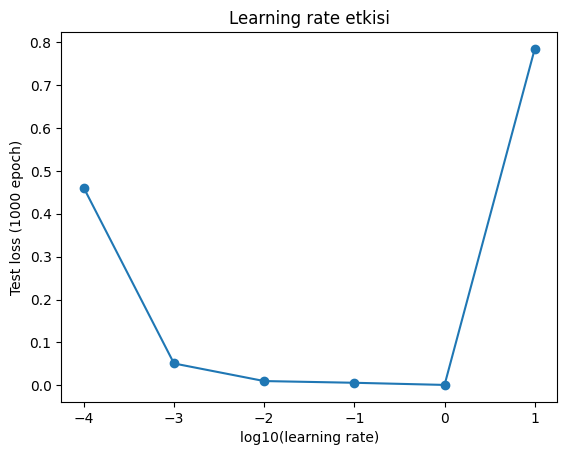

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np

learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
test_loss = [0.460, 0.051, 0.010, 0.006, 0.001, 0.784]   # ← Playground'dan okuduğun değerler, aynı sırayla

plt.plot(np.log10(learning_rates), test_loss, marker="o")
plt.xlabel("log10(learning rate)")
plt.ylabel("Test loss (1000 epoch)")
plt.title("Learning rate etkisi")
plt.show()

❗️ <u>Uyarı</u> ❗️  
Hem **çok düşük** hem de **çok yüksek** learning rate değerleri yüksek test loss’a yol açar… fakat **farklı nedenlerle**!

* **Düşük learning rate**:
  - Sinir ağının, orta seviyedeki bir learning rate’e benzer şekilde yakınsamasını sağlar
  - Ancak **çok daha yavaş** olur → yani **daha fazla epoch** gerekir

* **Yüksek learning rate**:
  - Algoritmanın tamamen **dağılmasına (diverge)** neden olur
  - Örneğin learning rate \( \alpha = 10 \) ve 400 epoch dene:
    - Loss değerinin sürekli değiştiğini görürsün
    - Bu durum, algoritmanın **farklı yerel minimumlara** yakınsadığını gösterir

🏁 Tebrikler!

💾 Not defterinizi `git add/commit/push` yapmayı unutmayın...